<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/06-Deep-Learning/01-PyTorch/03-PyTorch-Object-Detection/01_R_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy
import torch
import os
from detection_utils import intersection_over_union, non_max_suppression

!pip -q install selectivesearch
import selectivesearch
import cv2

  Preparing metadata (setup.py) ... done


In [31]:
import kagglehub
path = kagglehub.dataset_download("zaraks/pascal-voc-2007")

Using Colab cache for faster access to the 'pascal-voc-2007' dataset.


In [ ]:
import os
import xml.etree.ElementTree as ET

annotations_dir = None
images_dir = None

#The dataset is very messy or we are auto finding the folder's or dir's path we needs
for root_dir, dirs, files in os.walk(path):
    if "Annotations" in dirs:
        annotations_dir = os.path.join(root_dir, "Annotations")
    if "JPEGImages" in dirs:
        images_dir = os.path.join(root_dir, "JPEGImages")

if not annotations_dir or not images_dir:
    raise FileNotFoundError("Could not find Annotations or JPEGImages folders in the dataset.")

print(f"Found Annotations at: {annotations_dir}")
print(f"Found Images at: {images_dir}")
print("-" * 50)

#Extracting only the three classes for this small experiment
target_classes = {"person", "dog", "car"}
filtered_dataset = []

for xml_filename in os.listdir(annotations_dir):
    if not xml_filename.endswith(".xml"):
        continue

    xml_path = os.path.join(annotations_dir, xml_filename)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    image_path = os.path.join(images_dir, filename)

    target_objects = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        if class_name in target_classes:
            bndbox = obj.find("bndbox")
            xmin = int(float(bndbox.find("xmin").text))
            ymin = int(float(bndbox.find("ymin").text))
            xmax = int(float(bndbox.find("xmax").text))
            ymax = int(float(bndbox.find("ymax").text))

            target_objects.append({
                "class_name": class_name,
                "bbox": [xmin, ymin, xmax, ymax]
            })

    if len(target_objects) > 0:
        filtered_dataset.append({
            "image_path": image_path,
            "objects": target_objects
        })

print(f"Successfully processed {len(filtered_dataset)} images containing a person, dog, or car.")
print(f"Sample data: {filtered_dataset[0]}")

Found Annotations at: /root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/VOCtest_06-Nov-2007/VOCdevkit/VOC2007/Annotations
Found Images at: /root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/VOCtest_06-Nov-2007/VOCdevkit/VOC2007/JPEGImages
--------------------------------------------------
Successfully processed 2895 images containing a person, dog, or car.
Sample data: {'image_path': '/root/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/VOCtest_06-Nov-2007/VOCdevkit/VOC2007/JPEGImages/009125.jpg', 'objects': [{'class_name': 'car', 'bbox': [119, 180, 262, 235]}, {'class_name': 'person', 'bbox': [477, 172, 492, 208]}, {'class_name': 'person', 'bbox': [465, 177, 479, 209]}, {'class_name': 'person', 'bbox': [151, 178, 390, 375]}, {'class_name': 'person', 'bbox': [56, 166, 256, 375]}, {'class_name': 'person', 'bbox': [39, 167, 52, 193]}]}


In [ ]:
#While this code did work it just that we don't be able to show it the way i wanted it to be that is 4*4 grid of 16 image

#Randomly picking 16 images with ground truth box for visuallization
# import random
# from google.colab.patches import cv2_imshow

# Loop for puting the box and class name on the img
# for i in range(16):
#   random_idx=random.randint(0,len(filtered_dataset))
#   img=cv2.imread(filtered_dataset[random_idx]["image_path"])
#   for obj in filtered_dataset[random_idx]["objects"]:
#     class_name = obj["class_name"]
#     bbox = obj["bbox"]
#     cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
#     cv2.putText(img, class_name, (bbox[0], bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

#   cv2_imshow(img)
#   cv2.waitKey(0)
#   cv2.destroyAllWindows()

<Figure size 1000x1000 with 0 Axes>

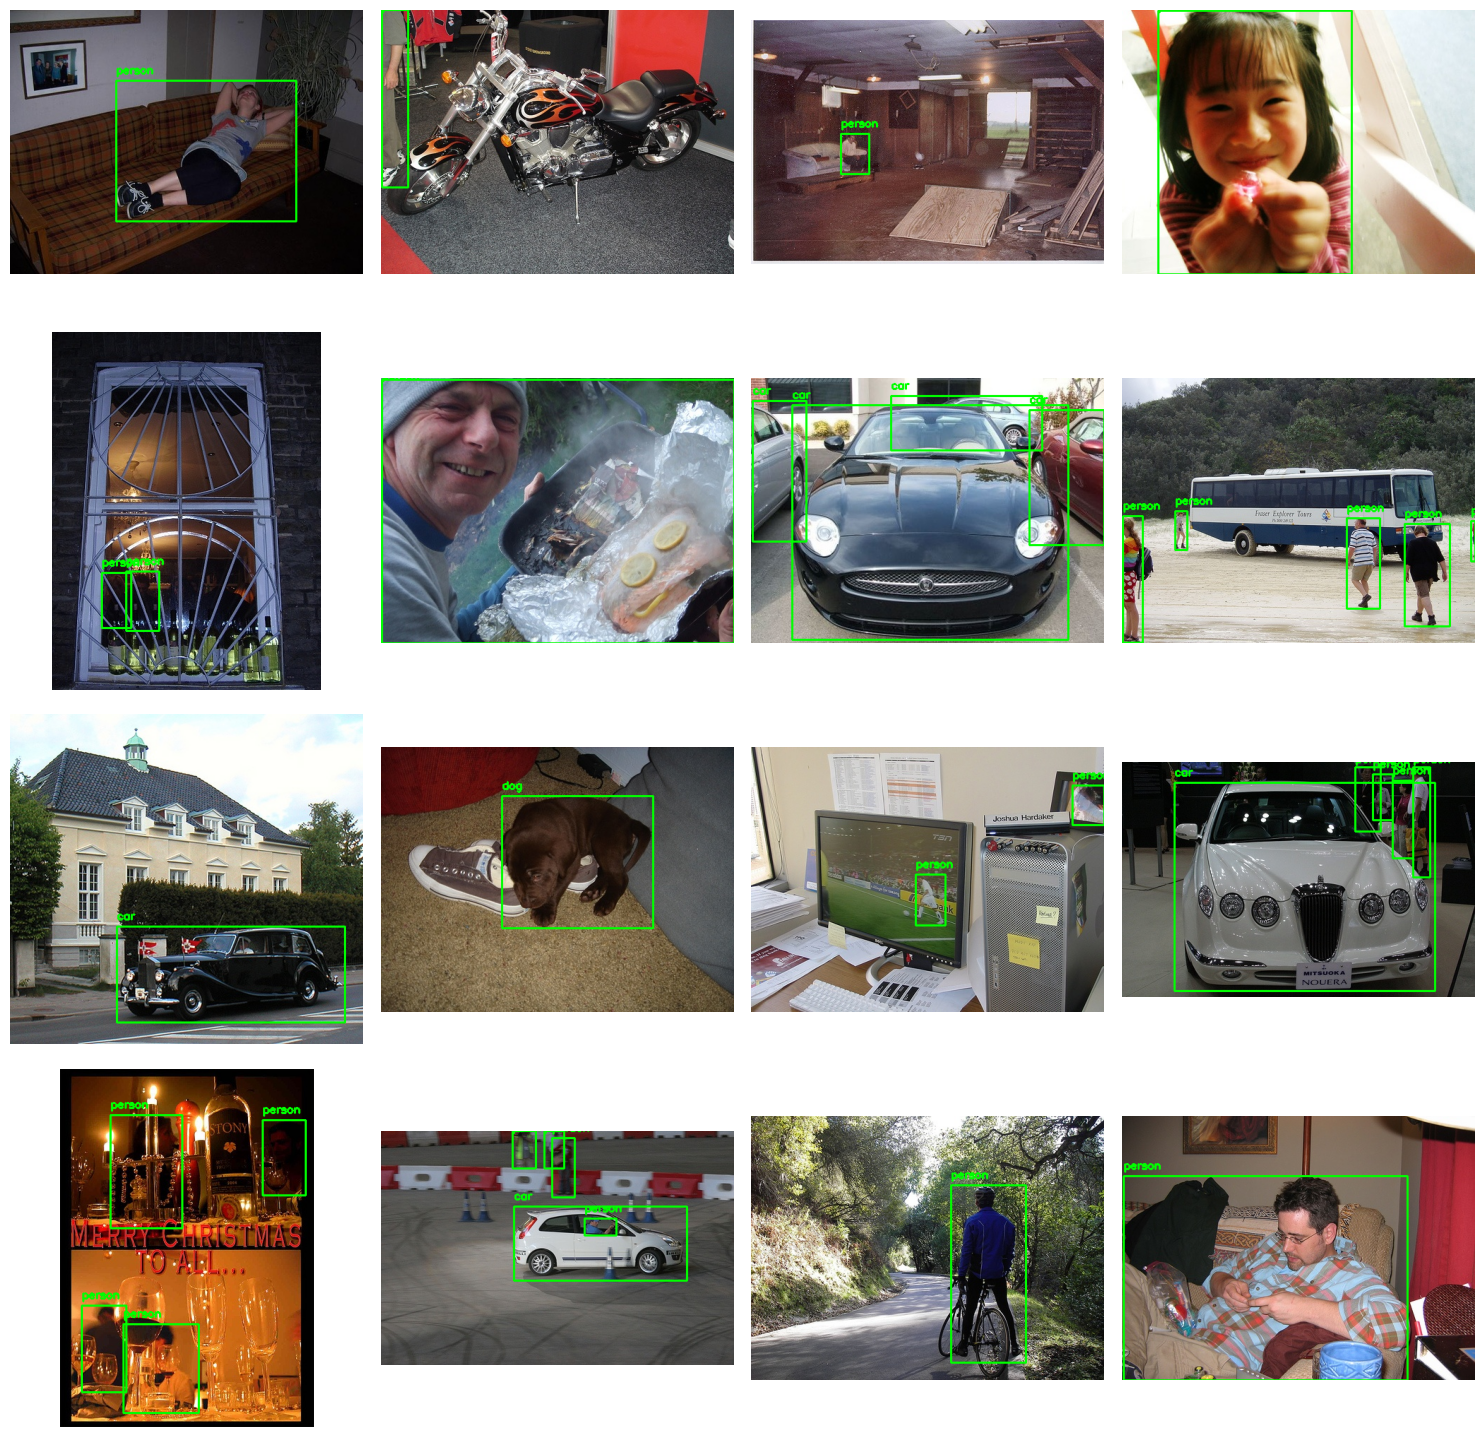

In [ ]:
import random
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 10))

sample_indices = random.sample(range(len(filtered_dataset)), 16) # Using the random.sample rather than randint for 16 unique indices

# Create a 4x4 grid for plot
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
axes = axes.flatten()

#Adding all the ground truth boxes for each img for visualization
for idx, ax in zip(sample_indices, axes):
    img = cv2.imread(filtered_dataset[idx]["image_path"])

    for obj in filtered_dataset[idx]["objects"]:
        class_name = obj["class_name"]
        bbox = obj["bbox"]

        cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
        cv2.putText(img, class_name, (bbox[0], max(0, bbox[1] - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img_rgb)
    ax.axis("off")

plt.tight_layout()

sns.despine()
plt.show()

In [ ]:
def extract_proposals(images,max_proposals=2000):
  '''
     images: cv2 images(H,W,C)
     max_proposals: int (max proposals per image default=2000)
  '''
  _,regions=selectivesearch.selective_search(images,scale=500,sigma=0.9,min_size=10)

  proposals=[]
  for r in regions:
    if r['rect'] == (0,0,images.shape[1],images.shape[0]):
      continue

    x,y,w,h=r['rect']
    if w>0 and h>0:
      proposals.append([x,y,x+w,y+h])

  proposals=list(set(tuple(x) for x in proposals))
  proposals=proposals[:max_proposals]

  return proposals[:max_proposals]

#### Saving a json file
This rcnn_proposals_data will contain the image path , seleative search proposals and ground truth.
* image_path
* croped_boxs
* ground_truth

In [ ]:
#proposal boxes and ground truth with img_path to a json file
import json

all_data=[]
output_file="rcnn_proposals_data.json"

for i in range(0,len(filtered_dataset)):
  img_path=filtered_dataset[i]["image_path"]
  img=cv2.imread(img_path)
  if img is None:
    continue

  croped_boxs= extract_proposals(img, max_proposals=500)

  all_data.append({
                  "image_path":img_path,
                  "croped_boxs":croped_boxs,
                  "ground_truth":filtered_dataset[i]["objects"]
                  })
  if (i + 1) % 25 == 0 or (i + 1) == len(filtered_dataset):
        print(f"Processed {i + 1}/{len(filtered_dataset)} images")

        with open(output_file, "w") as f:
            json.dump(all_data, f)

print(f"Successfully saved proposal data to {output_file}")

Processed 25/2878 images
Processed 50/2878 images
Processed 75/2878 images
Processed 100/2878 images
Processed 125/2878 images
Processed 150/2878 images
Processed 175/2878 images
Processed 200/2878 images
Processed 225/2878 images
Processed 250/2878 images
Processed 275/2878 images
Processed 300/2878 images
Processed 325/2878 images
Processed 350/2878 images
Processed 375/2878 images
Processed 400/2878 images
Processed 425/2878 images
Processed 450/2878 images
Processed 475/2878 images
Processed 500/2878 images
Processed 525/2878 images
Processed 550/2878 images
Processed 575/2878 images
Processed 600/2878 images
Processed 625/2878 images
Processed 650/2878 images
Processed 675/2878 images
Processed 700/2878 images
Processed 725/2878 images
Processed 750/2878 images
Processed 775/2878 images
Processed 800/2878 images
Processed 825/2878 images
Processed 850/2878 images
Processed 875/2878 images
Processed 900/2878 images
Processed 925/2878 images
Processed 950/2878 images
Processed 975/2

In [ ]:
import torch.nn as nn
import torchvision.models as model

resnet18=model.resnet18(weights=model.ResNet18_Weights.DEFAULT)
feature_extractor = nn.Sequential(*list(resnet18.children())[:-1])

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 120MB/s]


In [ ]:
feature_extractor

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [ ]:
class RCNN(nn.Module):
  def __init__(self,feature_extractor,num_classes):
    super(RCNN,self).__init__()
    self.feature_extractor=feature_extractor
    #Classifier block
    self.Classifier=nn.Sequential(
                                  nn.Linear(512,256),
                                  nn.ReLU(),
                                  nn.Dropout(0.3,inplace=False),
                                  nn.Linear(256,128),
                                  nn.ReLU(),
                                  nn.Dropout(0.3,inplace=False),
                                  nn.Linear(128,num_classes)
                                  )
    #Bbox block
    self.Bbox=nn.Sequential(
                            nn.Linear(512,256),
                            nn.ReLU(),
                            nn.Dropout(0.2),
                            nn.Linear(256,128),
                            nn.ReLU(),
                            nn.Dropout(0.2),
                            nn.Linear(128,4)
                            )
  def forward(self,x):
    features=self.feature_extractor(x)
    features=nn.Flatten(features)

    class_scores=self.Classifier(features)
    bbox_offset=self.Bbox(features)

    return class_scores,bbox_offset

In [ ]:
def bbox_delta(ground_truth,proposals):
  #For bbox_delta (x,y,w,h) is needed we have (x1,y1,x2,y2) so converting it.
  x1,y1,x2,y2=ground_truth
  xp1,yp1,xp2,yp2=proposals

  xg=(x1+x2)/2
  yg=(y1+y2)/2
  wg=x2-x1
  hg=y2-y1

  xp=(xp1+xp2)/2
  yp=(yp1+yp2)/2
  wp=xp2-xp1
  hp=yp2-yp1

  tx=(xg-xp)/wp
  ty=(yg-yp)/hp
  tw=torch.log(wg/wp)
  th=torch.log(hg/hp)

  bbox_delta=torch.stack([tx,ty,tw,th])

  return bbox_delta

def bbox_delta_to_box(bbox_delta,proposals):
  xp1,yp1,xp2,yp2=proposals
  tx,ty,tw,th=bbox_delta

  xp=(xp1+xp2)/2
  yp=(yp1+yp2)/2
  wp=xp2-xp1
  hp=yp2-yp1

  w=wp*torch.exp(tw)
  h=hp*torch.exp(th)

  x=xp+tx*wp
  y=yp+ty*hp

  box=torch.stack([x,y,w,h])
  refined_box=torch.stack([x-w/2,y-h/2,x+w/2,y+h/2])

  return box,refined_box


In [ ]:
#Checking the math of bbox_delta and bbox_delta_to_box
a=torch.tensor([23,43,28,49])
b=torch.tensor([26,30,33,40])
delta=bbox_delta(a,b)
print(f"delta: {delta}")
box,refined_box=bbox_delta_to_box(delta,b)
print(f"box: {box}")
print(f"refined_box: {refined_box}")

delta: tensor([-0.5714,  1.1000, -0.3365, -0.5108])
box: tensor([25.5000, 46.0000,  5.0000,  6.0000])
refined_box: tensor([23., 43., 28., 49.])


In [32]:
import json
from torch.utils.data import Dataset
import torchvision.transforms as transforms

class RCNNDataset(Dataset):
    def __init__(self, json_path, transform=None):
        """
        1. Loads the JSON file.
        2. Calculates IoU for proposals.
        3. Saves ONLY the metadata (paths, coords, labels) into self.samples.
        """
        self.transform = transform
        self.samples = []

        self.class_mapping = {"background": 0, "person": 1, "dog": 2, "car": 3}

        with open(json_path, 'r') as f:
            all_data = json.load(f)


        for item in all_data:
            img_path = item["image_path"]
            proposals = item["croped_boxs"]
            ground_truths = item["ground_truth"]

            positives = []
            negatives = []

            for prop in proposals:
                best_iou = 0
                best_gt_class = "background"
                best_gt_box = None

                # Check this proposal against all ground truth objects in the image

                for gt in ground_truths:
                    # Using detection_utils IoU function
                    iou = intersection_over_union(
                                                  torch.tensor(prop).unsqueeze(0),
                                                  torch.tensor(gt["bbox"]).unsqueeze(0),
                                                  box_format="corners"
                                                  ).item()

                    if iou > best_iou:
                        best_iou = iou
                        best_gt_class = gt["class_name"]
                        best_gt_box = gt["bbox"]

                # Categorize based on IoU Thresholds

                if best_iou >= 0.5:

                    delta = bbox_delta(torch.tensor(best_gt_box), torch.tensor(prop))
                    label = self.class_mapping[best_gt_class]
                    positives.append((img_path, prop, label, delta))

                elif best_iou < 0.3:

                    negatives.append((img_path, prop, 0, torch.zeros(4)))

            # Downsampling to speed up training (e.g., max 10 positives and 30 negatives per image)
            import random
            sampled_pos = random.sample(positives, min(len(positives), 10))
            sampled_neg = random.sample(negatives, min(len(negatives), 30))

            self.samples.extend(sampled_pos)
            self.samples.extend(sampled_neg)

        print(f"Dataset ready! Total training samples: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        """
        LAZY LOADING: The image is only read from the hard drive and cropped
        when the DataLoader explicitly requests this index.
        """
        img_path, prop_box, label, delta = self.samples[idx]

        # 1. Read Image
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"OpenCV could not read the image at: {img_path}. Did the Colab runtime wipe the cache?")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 2. Crop Proposal
        x1, y1, x2, y2 = map(int, prop_box)
        crop = img[y1:y2, x1:x2]

        # 3. Resize to fit ResNet-18
        crop_resized = cv2.resize(crop, (224, 224))

        # 4. Apply PyTorch transforms (ToTensor, Normalize)
        if self.transform:
            crop_tensor = self.transform(crop_resized)
        else:
            crop_tensor = torch.tensor(crop_resized).permute(2, 0, 1).float() / 255.0

        return crop_tensor, torch.tensor(label, dtype=torch.long), delta

#### Creating test and train data and dataset

In [23]:
with open("rcnn_proposals_data.json", 'r') as f:
            all_data = json.load(f)

print(f"So the Lenght of all_data is {len(all_data)}")
print(f"so train data(80% of all_data) will have a len of {int(len(all_data)*0.8)}")
print(f"so test data(20% of all_data) will have a len of {int(len(all_data)*0.2)}")

train_data=all_data[:int(len(all_data)*0.8)]
test_data=all_data[int(len(all_data)*0.8):]

with open("train_data.json", 'w') as f:
            json.dump(train_data, f)

with open("test_data.json", 'w') as f:
            json.dump(test_data, f)

So the Lenght of all_data is 2878
so train data(80% of all_data) will have a len of 2302
so test data(20% of all_data) will have a len of 575


In [24]:
with open("train_data.json", 'r') as f:
            train_data = json.load(f)

with open("test_data.json", 'r') as f:
            test_data = json.load(f)

print(f"So the Lenght of train_data is {len(train_data)}")
print(f"So the Lenght of test_data is {len(test_data)}")

So the Lenght of train_data is 2302
So the Lenght of test_data is 576


In [25]:
from torch.utils.data import DataLoader

BATCH_SIZE=32

transform=transforms.Compose([
                              transforms.ToTensor(),
                              transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                             ])

train_dataset=RCNNDataset(json_path="train_data.json",
                          transform=transform)
test_dataset=RCNNDataset(json_path="test_data.json",
                         transform=transform)

train_dataloader=DataLoader(
                            dataset=train_dataset,
                            batch_size=BATCH_SIZE,
                            num_workers=2,
                            pin_memory=True,
                            shuffle=True
                            )
test_dataloader=DataLoader(
                            dataset=test_dataset,
                            batch_size=BATCH_SIZE,
                            num_workers=2,
                            pin_memory=True,
                            shuffle=True
                            )

Dataset ready! Total training samples: 78559
Dataset ready! Total training samples: 19796


### Visualize

In [33]:
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7dd705073230>,
 <torch.utils.data.dataloader.DataLoader at 0x7dd704bde490>)

<Figure size 1000x1000 with 0 Axes>

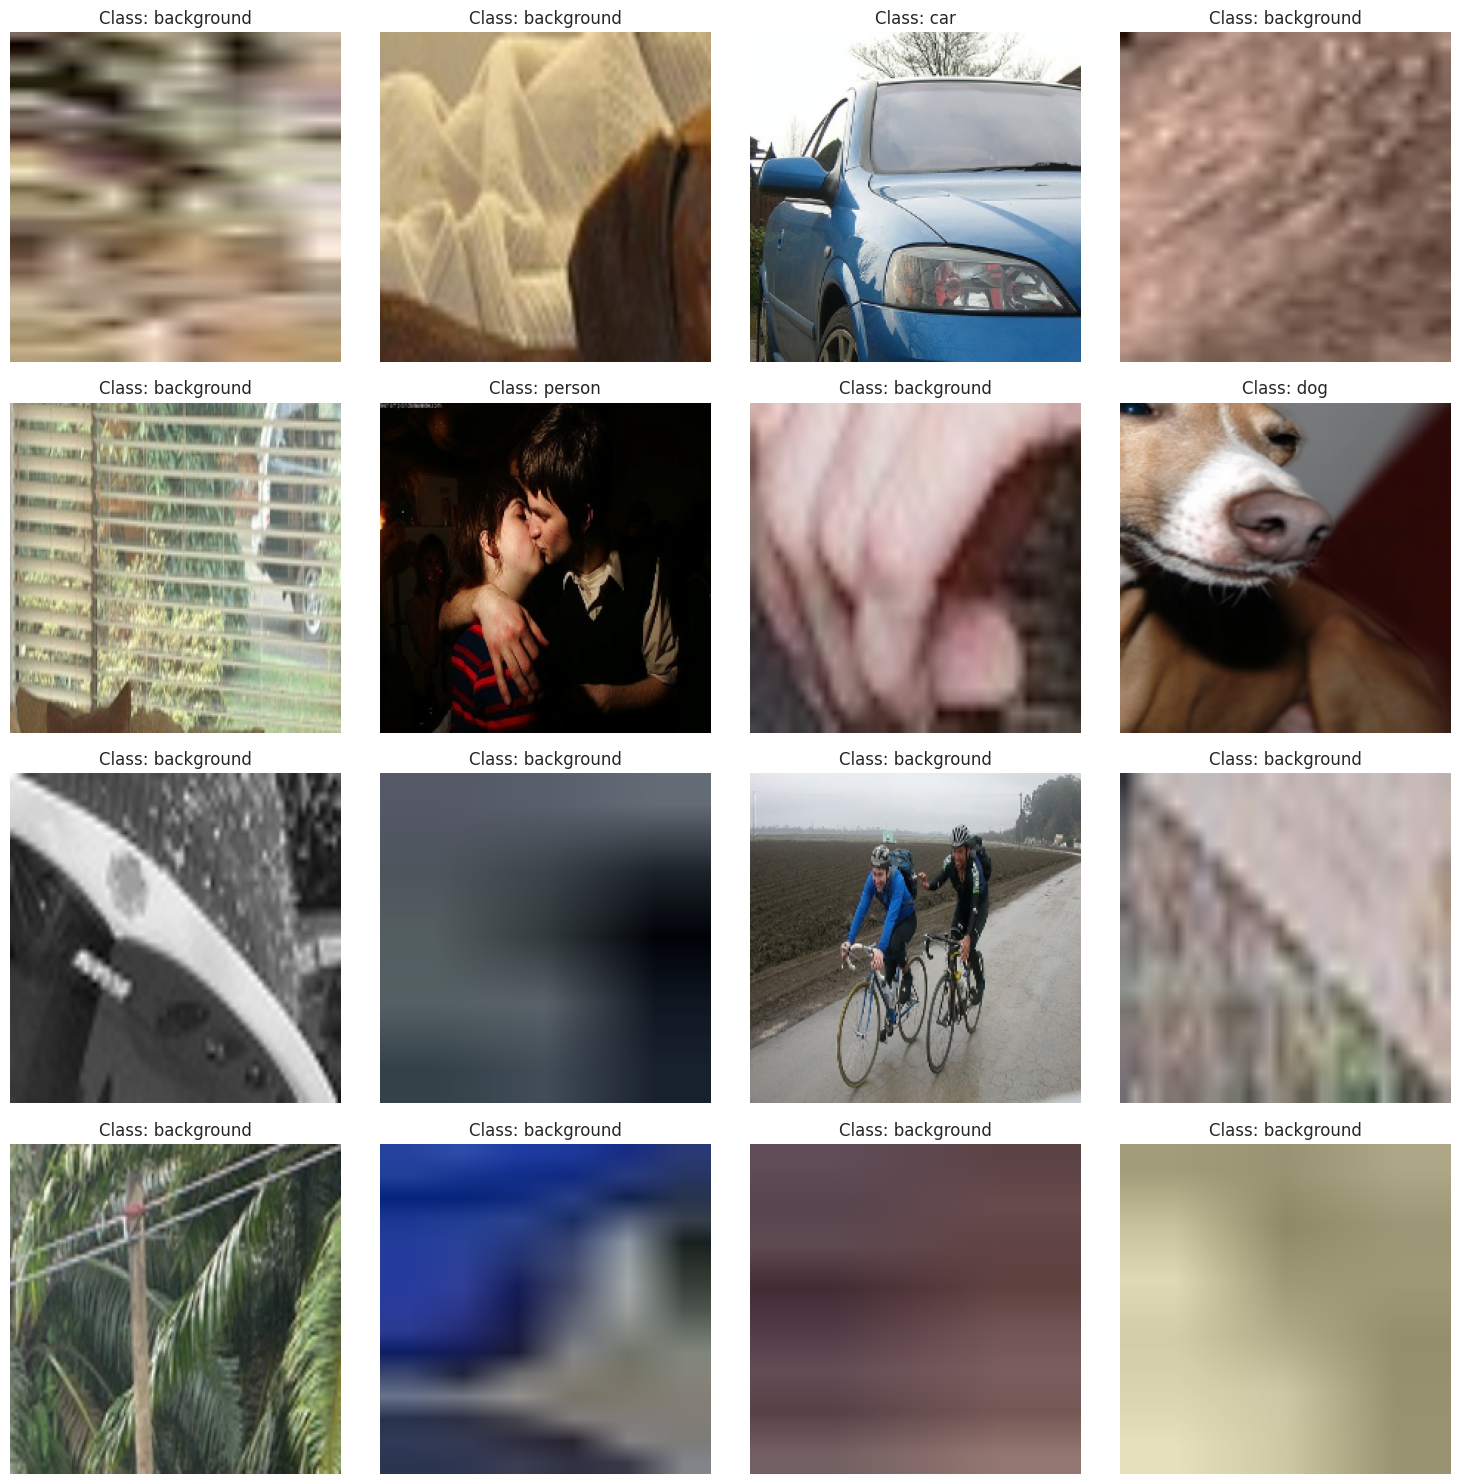

In [49]:
import numpy as np
import random
import PIL

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 10))

crop_tensor_batch,labels,delta=next(iter(train_dataloader))

sample_indices=random.sample(range(len(crop_tensor_batch)),16)

_,axes=plt.subplots(4,4,figsize=(15,15))
axes=axes.flatten()

for idx,ax in zip(sample_indices,axes):
  img=crop_tensor_batch[idx].permute(1,2,0).numpy()
  #Converting normalized to normal
  img=img*np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
  img=img.clip(0,1)

  label=labels[idx]
  if label==0:
    label="background"
  elif label==1:
    label="person"
  elif label==2:
    label="dog"
  elif label==3:
    label="car"

  ax.imshow(img)
  ax.axis("off")
  ax.set_title(f"Class: {label}")

plt.tight_layout()

sns.despine()
plt.show()